# 00_data_exploration

Placeholder notebook for initial data exploration.


In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set()
sns.set_style("white")


In [3]:
from datasetsforecast.m5 import M5

Y_df, X_df, S_df = M5.load(directory="data/m5")

In [4]:
Y_df

,unique_id,ds,y
0,FOODS_1_001_CA_1,2011-01-29,3.0
1,FOODS_1_001_CA_1,2011-01-30,0.0
2,FOODS_1_001_CA_1,2011-01-31,0.0
3,FOODS_1_001_CA_1,2011-02-01,1.0
4,FOODS_1_001_CA_1,2011-02-02,4.0
...,...,...,...
47649935,HOUSEHOLD_2_516_WI_3,2016-06-15,0.0
47649936,HOUSEHOLD_2_516_WI_3,2016-06-16,1.0
47649937,HOUSEHOLD_2_516_WI_3,2016-06-17,0.0
47649938,HOUSEHOLD_2_516_WI_3,2016-06-18,0.0


In [5]:
X_df

,unique_id,ds,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1,2011-01-29,nan,nan,nan,nan,0,0,0,2.00
1,FOODS_1_001_CA_1,2011-01-30,nan,nan,nan,nan,0,0,0,2.00
2,FOODS_1_001_CA_1,2011-01-31,nan,nan,nan,nan,0,0,0,2.00
3,FOODS_1_001_CA_1,2011-02-01,nan,nan,nan,nan,1,1,0,2.00
4,FOODS_1_001_CA_1,2011-02-02,nan,nan,nan,nan,1,0,1,2.00
...,...,...,...,...,...,...,...,...,...,...
47649935,HOUSEHOLD_2_516_WI_3,2016-06-15,nan,nan,nan,nan,0,1,1,5.94
47649936,HOUSEHOLD_2_516_WI_3,2016-06-16,nan,nan,nan,nan,0,0,0,5.94
47649937,HOUSEHOLD_2_516_WI_3,2016-06-17,nan,nan,nan,nan,0,0,0,5.94
47649938,HOUSEHOLD_2_516_WI_3,2016-06-18,nan,nan,nan,nan,0,0,0,5.94


In [6]:
S_df

,unique_id,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1969,FOODS_1_001_CA_2,FOODS_1_001,FOODS_1,FOODS,CA_2,CA
3938,FOODS_1_001_CA_3,FOODS_1_001,FOODS_1,FOODS,CA_3,CA
5907,FOODS_1_001_CA_4,FOODS_1_001,FOODS_1,FOODS,CA_4,CA
7875,FOODS_1_001_TX_1,FOODS_1_001,FOODS_1,FOODS,TX_1,TX
...,...,...,...,...,...,...
47640137,HOUSEHOLD_2_516_TX_2,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,TX_2,TX
47642105,HOUSEHOLD_2_516_TX_3,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,TX_3,TX
47644074,HOUSEHOLD_2_516_WI_1,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_1,WI
47646040,HOUSEHOLD_2_516_WI_2,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_2,WI


In [7]:
for name, df in {"Y_df": Y_df, "X_df": X_df, "S_df": S_df}.items():
    print(f"\n{name}")
    print(df.shape)
    print(df.head())
    print(df.dtypes)


Y_df
(47649940, 3)
          unique_id         ds    y
0  FOODS_1_001_CA_1 2011-01-29  3.0
1  FOODS_1_001_CA_1 2011-01-30  0.0
2  FOODS_1_001_CA_1 2011-01-31  0.0
3  FOODS_1_001_CA_1 2011-02-01  1.0
4  FOODS_1_001_CA_1 2011-02-02  4.0
unique_id          category
ds           datetime64[ns]
y                   float32
dtype: object

X_df
(47649940, 10)
          unique_id         ds event_name_1 event_type_1 event_name_2  \
0  FOODS_1_001_CA_1 2011-01-29          nan          nan          nan   
1  FOODS_1_001_CA_1 2011-01-30          nan          nan          nan   
2  FOODS_1_001_CA_1 2011-01-31          nan          nan          nan   
3  FOODS_1_001_CA_1 2011-02-01          nan          nan          nan   
4  FOODS_1_001_CA_1 2011-02-02          nan          nan          nan   

  event_type_2  snap_CA  snap_TX  snap_WI  sell_price  
0          nan        0        0        0         2.0  
1          nan        0        0        0         2.0  
2          nan        0        0      

In [8]:
print("Date range:", Y_df["ds"].min(), "to", Y_df["ds"].max())
print("Number of series:", Y_df["unique_id"].nunique())
print("Rows:", len(Y_df))

Date range: 2011-01-29 00:00:00 to 2016-06-19 00:00:00
Number of series: 30490
Rows: 47649940


In [21]:
m5 = (
    Y_df
    .merge(X_df, on=["unique_id", "ds"], how="left")
    .merge(S_df, on="unique_id", how="left")
)

m5.head()

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,2011-01-29,3.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_1,2011-01-30,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
2,FOODS_1_001_CA_1,2011-01-31,0.0,nan,nan,nan,nan,0,0,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
3,FOODS_1_001_CA_1,2011-02-01,1.0,nan,nan,nan,nan,1,1,0,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
4,FOODS_1_001_CA_1,2011-02-02,4.0,nan,nan,nan,nan,1,0,1,2.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA


In [10]:
# Missing values
m5.isna().mean().sort_values(ascending=False).head(20)

unique_id       0.0
ds              0.0
y               0.0
event_name_1    0.0
event_type_1    0.0
event_name_2    0.0
event_type_2    0.0
snap_CA         0.0
snap_TX         0.0
snap_WI         0.0
sell_price      0.0
item_id         0.0
dept_id         0.0
cat_id          0.0
store_id        0.0
state_id        0.0
dtype: float64

In [11]:
# Duplicate check
m5.duplicated(subset=["unique_id", "ds"]).sum()

np.int64(0)

In [12]:
# Negative sales check
(m5["y"] < 0).sum()

np.int64(0)

In [25]:
# Series length by item-store
series_lengths = (
    m5.groupby("unique_id")["ds"]
    .agg(["min", "max", "count"])
    .reset_index()
)

series_lengths.describe()

/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_12203/673892208.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m5.groupby("unique_id")["ds"]


,min,max,count
count,30490,30490,30490.000000
mean,2012-03-10 04:40:03.935716608,2016-06-19 00:00:00.000000256,1562.805510
min,2011-01-29 00:00:00,2016-06-19 00:00:00,124.000000
25%,2011-01-30 00:00:00,2016-06-19 00:00:00,1203.000000
50%,2011-07-07 00:00:00,2016-06-19 00:00:00,1810.000000
75%,2013-03-05 00:00:00,2016-06-19 00:00:00,1968.000000
max,2016-02-17 00:00:00,2016-06-19 00:00:00,1969.000000
std,NaN,NaN,477.176658


In [26]:
S_df[["state_id", "store_id", "cat_id", "dept_id", "item_id"]].nunique()

state_id       3
store_id      10
cat_id         3
dept_id        7
item_id     3049
dtype: int64

In [27]:
S_df.groupby(["cat_id", "dept_id"])["item_id"].nunique()

/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_12203/234878364.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  S_df.groupby(["cat_id", "dept_id"])["item_id"].nunique()


cat_id     dept_id    
HOBBIES    HOBBIES_1      416
           HOBBIES_2      149
           HOUSEHOLD_1      0
           HOUSEHOLD_2      0
           FOODS_1          0
           FOODS_2          0
           FOODS_3          0
HOUSEHOLD  HOBBIES_1        0
           HOBBIES_2        0
           HOUSEHOLD_1    532
           HOUSEHOLD_2    515
           FOODS_1          0
           FOODS_2          0
           FOODS_3          0
FOODS      HOBBIES_1        0
           HOBBIES_2        0
           HOUSEHOLD_1      0
           HOUSEHOLD_2      0
           FOODS_1        216
           FOODS_2        398
           FOODS_3        823
Name: item_id, dtype: int64

In [28]:
hierarchy_summary = (
    S_df.groupby(["state_id", "store_id", "cat_id", "dept_id"])
    .agg(series_count=("unique_id", "nunique"))
    .reset_index()
    .sort_values("series_count", ascending=False)
)

hierarchy_summary.head(20)

/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_12203/1705793034.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  S_df.groupby(["state_id", "store_id", "cat_id", "dept_id"])


,state_id,store_id,cat_id,dept_id,series_count
629,WI,WI_3,FOODS,FOODS_3,823
587,WI,WI_1,FOODS,FOODS_3,823
83,CA,CA_4,FOODS,FOODS_3,823
314,TX,TX_1,FOODS,FOODS_3,823
20,CA,CA_1,FOODS,FOODS_3,823
335,TX,TX_2,FOODS,FOODS_3,823
41,CA,CA_2,FOODS,FOODS_3,823
62,CA,CA_3,FOODS,FOODS_3,823
356,TX,TX_3,FOODS,FOODS_3,823
608,WI,WI_2,FOODS,FOODS_3,823


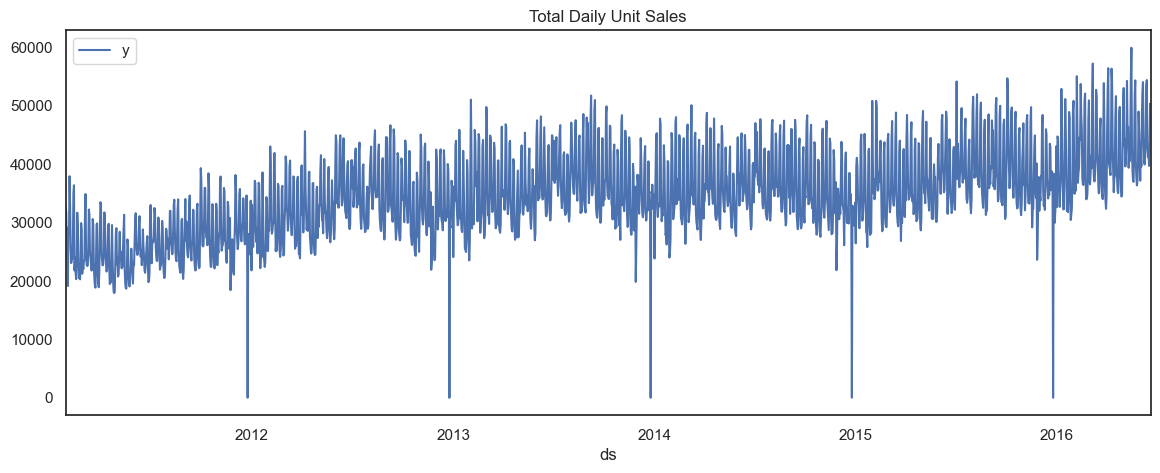

In [110]:
daily_sales = (
    m5.groupby("ds")["y"]
    .sum()
    .reset_index()
)

daily_sales.plot(x="ds", y="y", figsize=(14, 5), title="Total Daily Unit Sales");

In [33]:
category_daily = (
    m5.groupby(["ds", "cat_id"], observed=True)["y"]
    .sum()
    .reset_index()
)

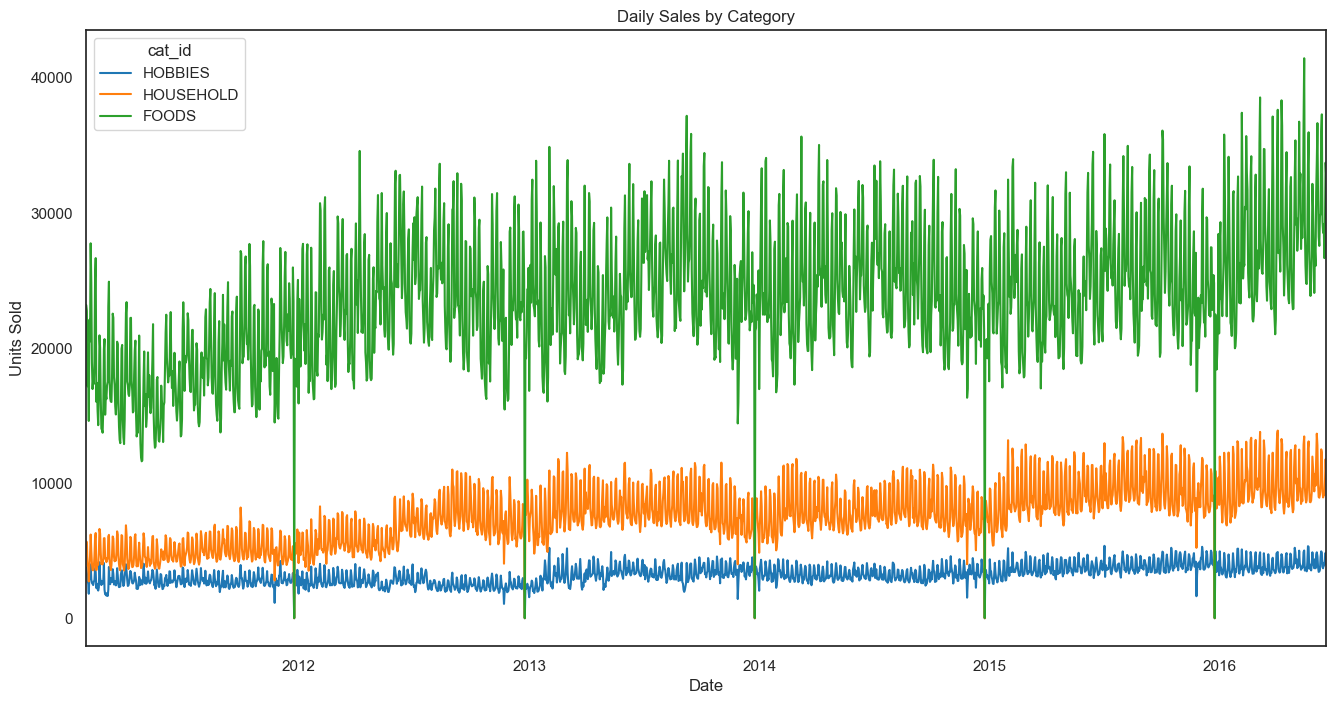

In [111]:
category_pivot = category_daily.pivot(
    index="ds",
    columns="cat_id",
    values="y"
)

ax = category_pivot.plot(
    figsize=(16, 8),
    title="Daily Sales by Category",
    color=["tab:blue", "tab:orange", "tab:green"],
)

ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")
plt.show()

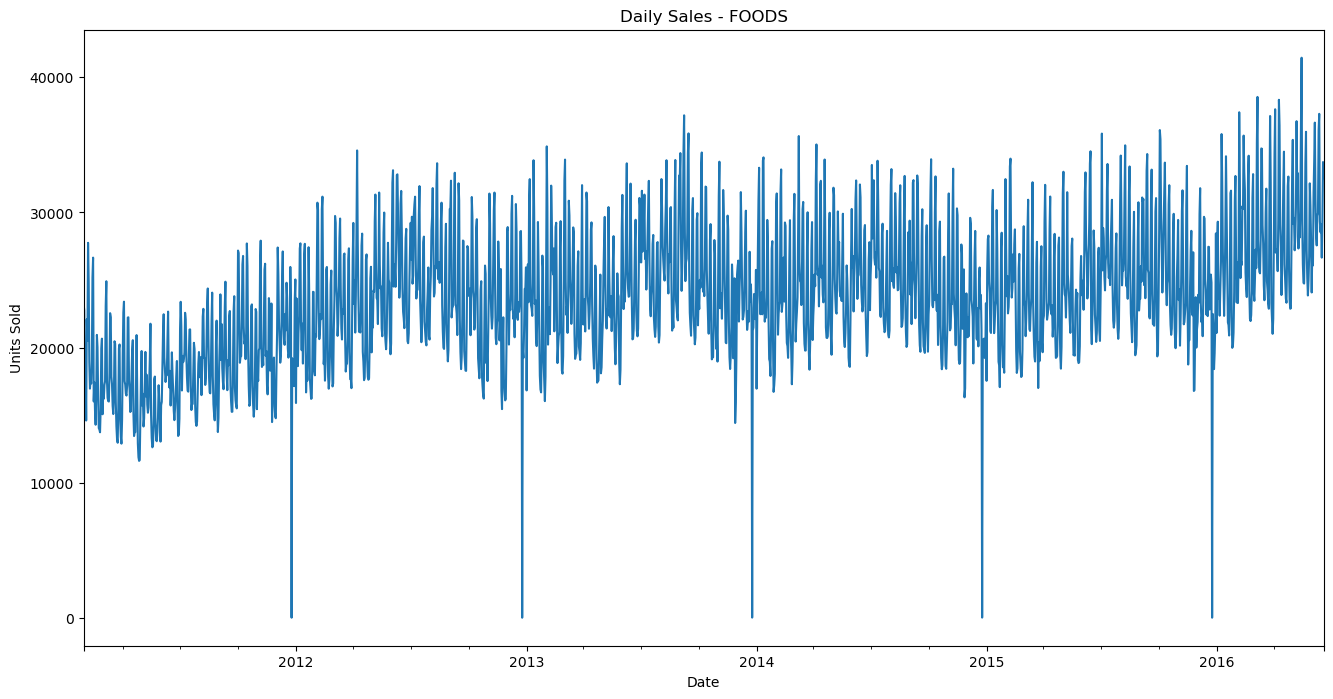

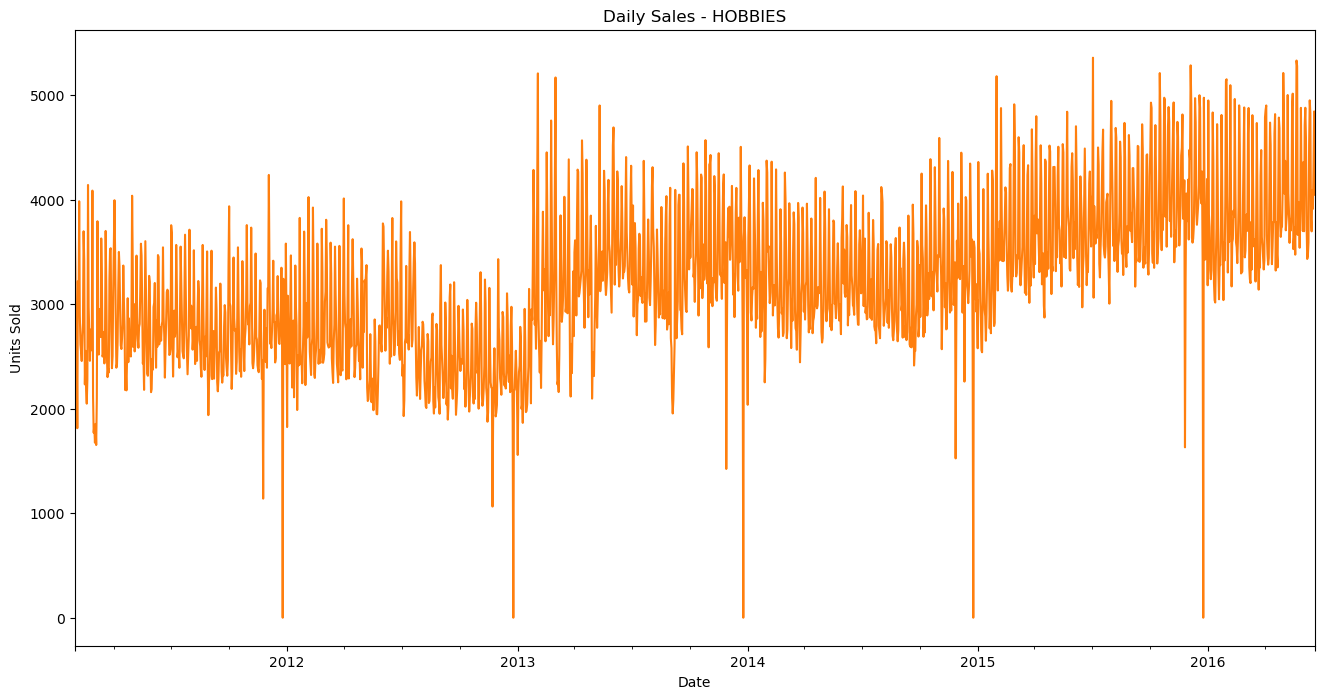

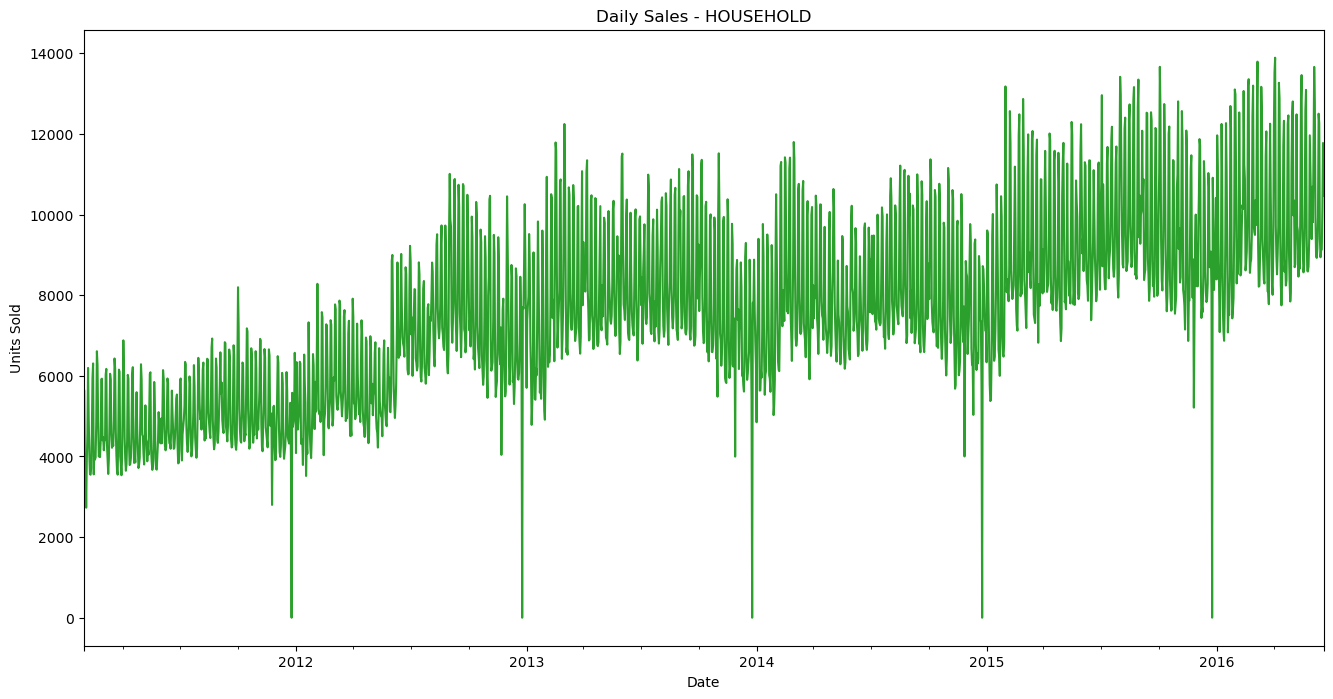

In [35]:
category_colors = {
    "FOODS": "tab:blue",
    "HOBBIES": "tab:orange",
    "HOUSEHOLD": "tab:green",
}

for cat in sorted(category_daily["cat_id"].unique()):
    data = category_daily[category_daily["cat_id"] == cat]

    ax = data.plot(
        x="ds",
        y="y",
        figsize=(16, 8),
        title=f"Daily Sales - {cat}",
        legend=False,
        color=category_colors.get(cat, "tab:gray"),
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Units Sold")
    plt.show()

In [ ]:
zero_category_days = category_daily[category_daily["y"] == 0]
zero_category_days

,ds,cat_id,y
990,2011-12-25,HOBBIES,0.0
991,2011-12-25,HOUSEHOLD,0.0
2088,2012-12-25,HOBBIES,0.0
2089,2012-12-25,HOUSEHOLD,0.0
3183,2013-12-25,HOBBIES,0.0
3184,2013-12-25,HOUSEHOLD,0.0
4278,2014-12-25,HOBBIES,0.0
4279,2014-12-25,HOUSEHOLD,0.0
5373,2015-12-25,HOBBIES,0.0


In [41]:
category_daily_no_zeros = category_daily[category_daily["y"] != 0].copy()

In [46]:
(category_daily_no_zeros["y"] == 0).sum()

np.int64(0)

In [47]:
category_daily_no_zeros.groupby("cat_id")["y"].min()

/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_12203/368512538.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_daily_no_zeros.groupby("cat_id")["y"].min()


cat_id
HOBBIES      1064.0
HOUSEHOLD       1.0
FOODS          11.0
Name: y, dtype: float32

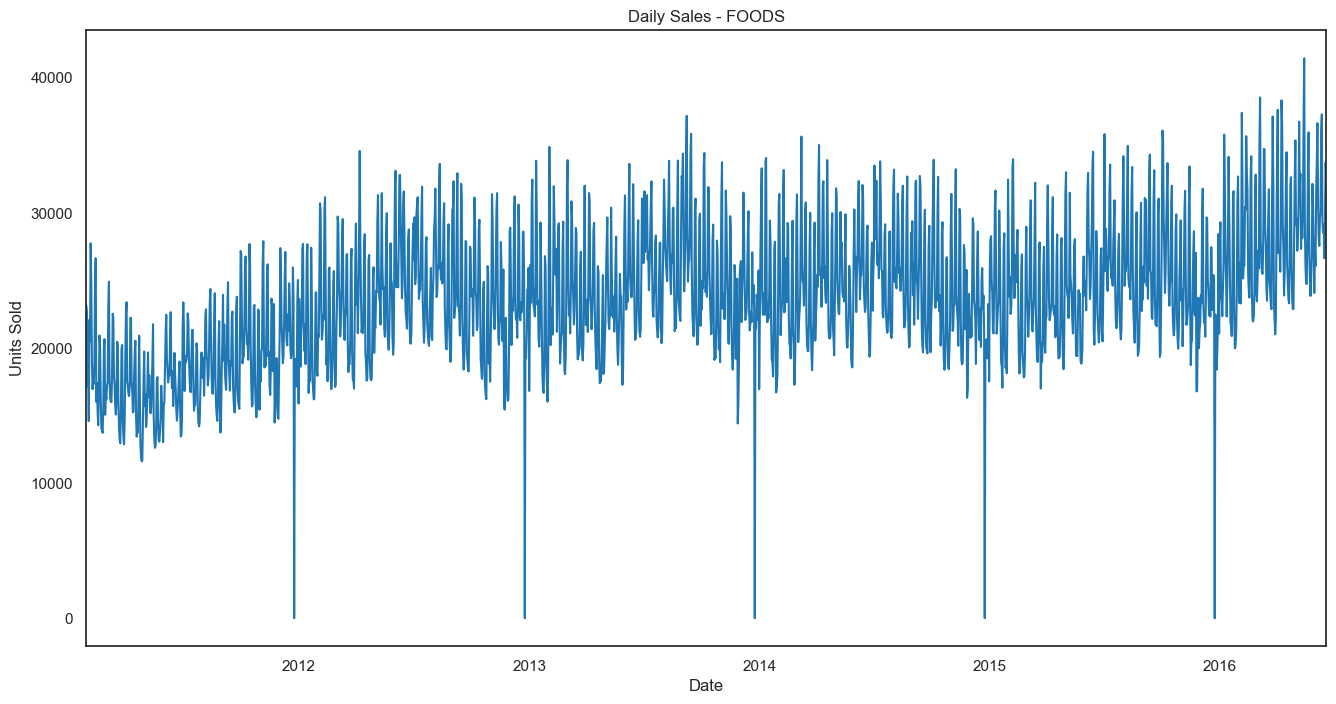

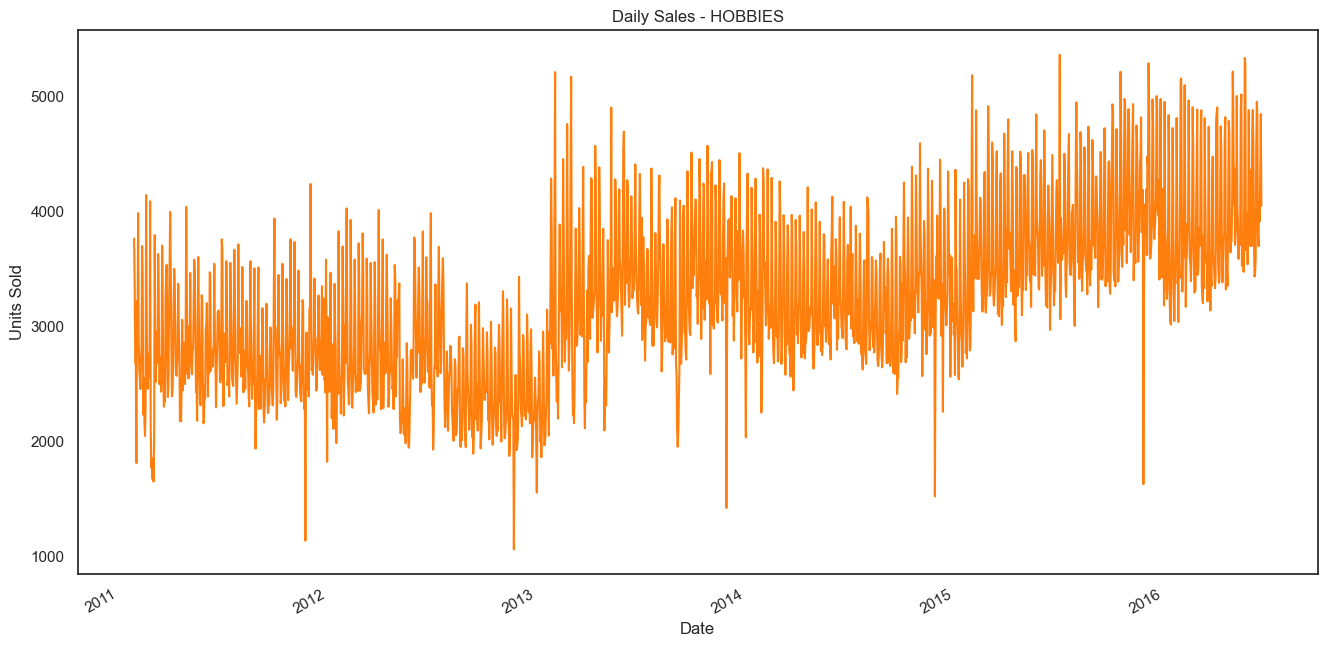

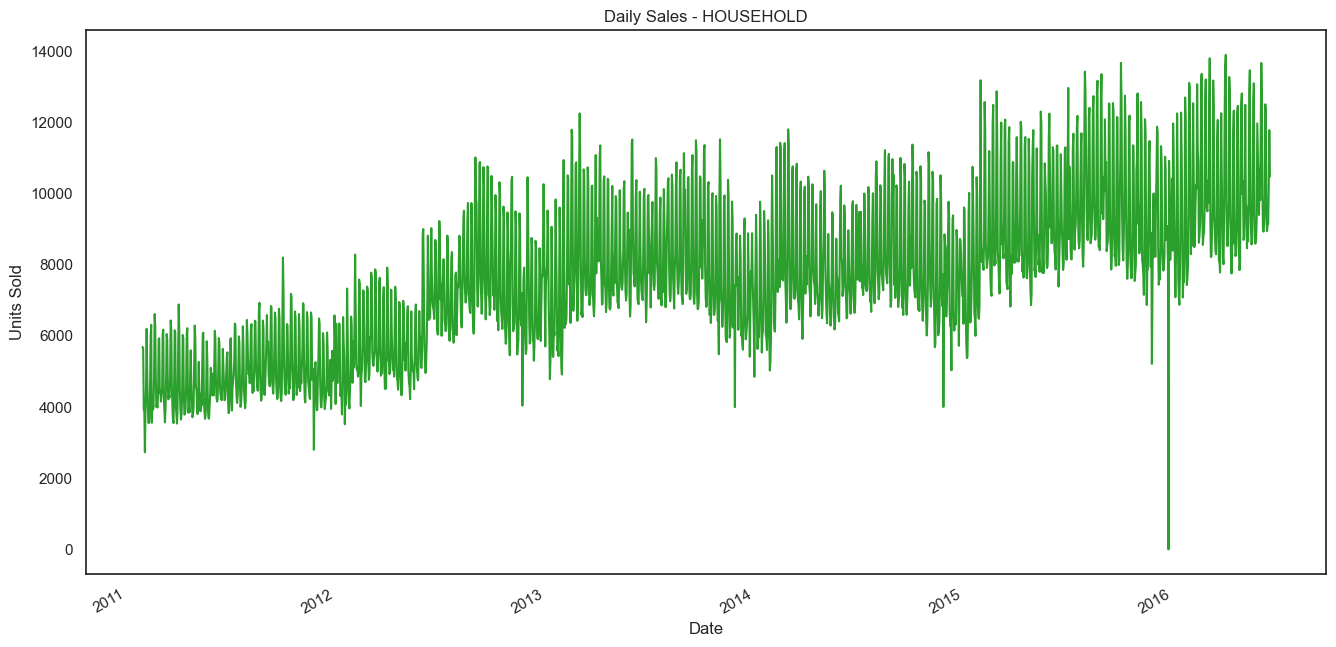

In [112]:
for cat in sorted(category_daily_no_zeros["cat_id"].unique()):
    data = (
        category_daily_no_zeros[category_daily_no_zeros["cat_id"] == cat]
        .sort_values("ds")
    )

    ax = data.plot(
        x="ds",
        y="y",
        figsize=(16, 8),
        title=f"Daily Sales - {cat}",
        legend=False,
        color=category_colors.get(cat, "tab:gray"),
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Units Sold")
    plt.show()

In [59]:
low_sales_days = (
    category_daily_no_zeros
    .assign(
        p01_by_category=category_daily_no_zeros.groupby("cat_id")["y"].transform(
            lambda s: s.quantile(0.01)
        )
    )
    .loc[lambda df: df["y"] <= df["p01_by_category"]]
    .sort_values(["cat_id", "y"])
)

low_sales_days

/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_12203/835271611.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p01_by_category=category_daily_no_zeros.groupby("cat_id")["y"].transform(


,ds,cat_id,y,p01_by_category
1989,2012-11-22,HOBBIES,1064.0,1940.89
897,2011-11-24,HOBBIES,1140.0,1940.89
3102,2013-11-28,HOBBIES,1424.0,1940.89
4194,2014-11-27,HOBBIES,1525.0,1940.89
2109,2013-01-01,HOBBIES,1558.0,1940.89
5286,2015-11-26,HOBBIES,1631.0,1940.89
102,2011-03-04,HOBBIES,1653.0,1940.89
96,2011-03-02,HOBBIES,1675.0,1940.89
90,2011-02-28,HOBBIES,1771.0,1940.89
12,2011-02-02,HOBBIES,1814.0,1940.89


In [60]:
category_daily["is_christmas"] = (
    (category_daily["ds"].dt.month == 12) &
    (category_daily["ds"].dt.day == 25)
)

category_daily["is_new_years_day"] = (
    (category_daily["ds"].dt.month == 1) &
    (category_daily["ds"].dt.day == 1)
)

category_daily["is_thanksgiving_window"] = (
    (category_daily["ds"].dt.month == 11) &
    (category_daily["ds"].dt.day.between(22, 28))
)

In [63]:
category_daily_model = category_daily.loc[
    ~(
        category_daily["is_christmas"] |
        category_daily["is_new_years_day"] |
        category_daily["is_thanksgiving_window"]
    )
].copy()

In [64]:
category_daily_events = (
    m5.groupby(["ds", "cat_id"], observed=True)
    .agg(
        y=("y", "sum"),
        event_name_1=("event_name_1", "first"),
        event_type_1=("event_type_1", "first"),
        event_name_2=("event_name_2", "first"),
        event_type_2=("event_type_2", "first"),
    )
    .reset_index()
)

In [65]:
lowest_days_with_events = (
    category_daily_events
    .assign(
        p01_by_category=category_daily_events.groupby("cat_id")["y"].transform(
            lambda s: s.quantile(0.01)
        )
    )
    .loc[lambda df: df["y"] <= df["p01_by_category"]]
    .sort_values(["cat_id", "y"])
)

lowest_days_with_events

/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_12203/1237104428.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p01_by_category=category_daily_events.groupby("cat_id")["y"].transform(


,ds,cat_id,y,event_name_1,event_type_1,event_name_2,event_type_2,p01_by_category
990,2011-12-25,HOBBIES,0.0,Christmas,National,nan,nan,1872.48
2088,2012-12-25,HOBBIES,0.0,Christmas,National,nan,nan,1872.48
3183,2013-12-25,HOBBIES,0.0,Christmas,National,nan,nan,1872.48
4278,2014-12-25,HOBBIES,0.0,Christmas,National,nan,nan,1872.48
5373,2015-12-25,HOBBIES,0.0,Christmas,National,nan,nan,1872.48
1989,2012-11-22,HOBBIES,1064.0,Thanksgiving,National,nan,nan,1872.48
897,2011-11-24,HOBBIES,1140.0,Thanksgiving,National,nan,nan,1872.48
3102,2013-11-28,HOBBIES,1424.0,Thanksgiving,National,nan,nan,1872.48
4194,2014-11-27,HOBBIES,1525.0,Thanksgiving,National,nan,nan,1872.48
2109,2013-01-01,HOBBIES,1558.0,NewYear,National,nan,nan,1872.48


In [ ]:
christmas_detail = m5[
    (m5["ds"].dt.month == 12) &
    (m5["ds"].dt.day == 25) &
    (m5["y"] > 0)
].copy()

christmas_detail

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,item_id,dept_id,cat_id,store_id,state_id,dayofweek,month,year
1383201,FOODS_1_082_TX_3,2014-12-25,1.0,Christmas,National,nan,nan,0,0,0,0.98,FOODS_1_082,FOODS_1,FOODS,TX_3,TX,Thursday,12,2014
1468548,FOODS_1_087_CA_3,2012-12-25,1.0,Christmas,National,nan,nan,0,0,0,5.23,FOODS_1_087,FOODS_1,FOODS,CA_3,CA,Tuesday,12,2012
1635423,FOODS_1_096_TX_3,2015-12-25,1.0,Christmas,National,nan,nan,0,0,0,6.18,FOODS_1_096,FOODS_1,FOODS,TX_3,TX,Friday,12,2015
2046655,FOODS_1_122_TX_3,2014-12-25,1.0,Christmas,National,nan,nan,0,0,0,1.98,FOODS_1_122,FOODS_1,FOODS,TX_3,TX,Thursday,12,2014
5396938,FOODS_2_125_TX_2,2014-12-25,1.0,Christmas,National,nan,nan,0,0,0,2.22,FOODS_2_125,FOODS_2,FOODS,TX_2,TX,Thursday,12,2014
10526146,FOODS_3_080_CA_2,2014-12-25,1.0,Christmas,National,nan,nan,0,0,0,1.68,FOODS_3_080,FOODS_3,FOODS,CA_2,CA,Thursday,12,2014
10533657,FOODS_3_080_TX_2,2013-12-25,1.0,Christmas,National,nan,nan,0,0,0,1.58,FOODS_3_080,FOODS_3,FOODS,TX_2,TX,Wednesday,12,2013
10538325,FOODS_3_080_WI_1,2015-12-25,1.0,Christmas,National,nan,nan,0,0,0,1.68,FOODS_3_080,FOODS_3,FOODS,WI_1,WI,Friday,12,2015
10539199,FOODS_3_080_WI_2,2012-12-25,1.0,Christmas,National,nan,nan,0,0,0,1.58,FOODS_3_080,FOODS_3,FOODS,WI_2,WI,Tuesday,12,2012
11535571,FOODS_3_144_CA_2,2015-12-25,1.0,Christmas,National,nan,nan,0,0,0,1.98,FOODS_3_144,FOODS_3,FOODS,CA_2,CA,Friday,12,2015


In [71]:
christmas_store_sales = (
    christmas_detail
    .assign(year=christmas_detail["ds"].dt.year)
    .groupby(["year", "cat_id", "state_id", "store_id"], observed=True)
    .agg(
        total_sales=("y", "sum"),
        selling_items=("item_id", "nunique"),
        selling_series=("unique_id", "nunique"),
    )
    .reset_index()
    .sort_values(["year", "cat_id", "total_sales"], ascending=[True, True, False])
)

christmas_store_sales

,year,cat_id,state_id,store_id,total_sales,selling_items,selling_series
0,2011,FOODS,CA,CA_2,7.0,2,2
3,2011,FOODS,WI,WI_2,3.0,3,3
2,2011,FOODS,TX,TX_3,2.0,2,2
1,2011,FOODS,CA,CA_3,1.0,1,1
5,2012,FOODS,CA,CA_3,4.0,4,4
7,2012,FOODS,WI,WI_2,3.0,3,3
4,2012,FOODS,CA,CA_2,2.0,2,2
6,2012,FOODS,TX,TX_3,2.0,2,2
11,2013,FOODS,TX,TX_2,11.0,4,4
9,2013,FOODS,CA,CA_3,3.0,2,2


In [73]:
category_daily_raw = (
    m5.groupby(["ds", "cat_id"], observed=True)["y"]
    .sum()
    .reset_index()
)

In [74]:
category_daily_event_adjusted = category_daily_raw.copy()

category_daily_event_adjusted["is_christmas"] = (
    (category_daily_event_adjusted["ds"].dt.month == 12) &
    (category_daily_event_adjusted["ds"].dt.day == 25)
)

category_daily_event_adjusted["is_new_years_day"] = (
    (category_daily_event_adjusted["ds"].dt.month == 1) &
    (category_daily_event_adjusted["ds"].dt.day == 1)
)

category_daily_event_adjusted["is_thanksgiving_window"] = (
    (category_daily_event_adjusted["ds"].dt.month == 11) &
    (category_daily_event_adjusted["ds"].dt.day.between(22, 28))
)

In [75]:
category_daily_normalized = category_daily_raw.loc[
    ~(
        (category_daily_raw["ds"].dt.month == 12) &
        (category_daily_raw["ds"].dt.day == 25)
    )
].copy()

In [83]:
print(category_daily_raw.groupby("cat_id")["y"].describe())

            count          mean          std   min      25%      50%      75%  \
cat_id                                                                          
HOBBIES    1969.0   3228.021240   718.735474   0.0   2709.0   3203.0   3679.0   
HOUSEHOLD  1969.0   7643.882324  2222.211914   0.0   6117.0   7494.0   9108.0   
FOODS      1969.0  23742.781250  4990.160645  11.0  20424.0  23377.0  26974.0   

               max  
cat_id              
HOBBIES     5360.0  
HOUSEHOLD  13889.0  
FOODS      41447.0  


/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_12203/3338701207.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(category_daily_raw.groupby("cat_id")["y"].describe())


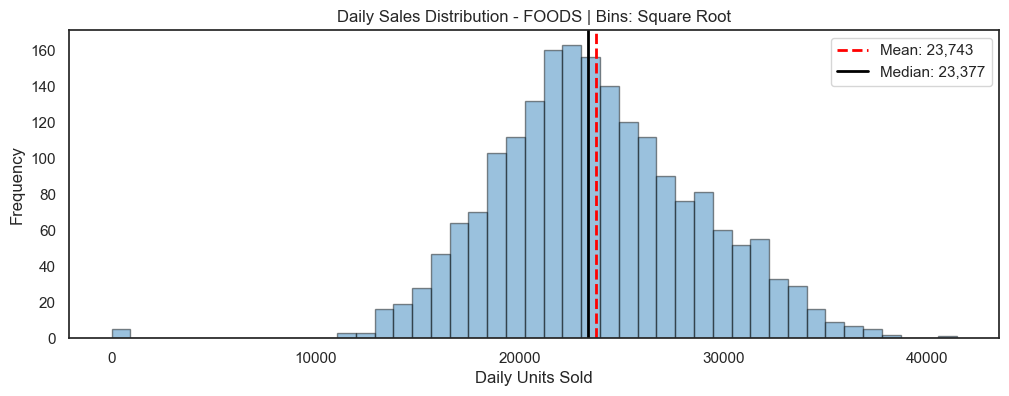

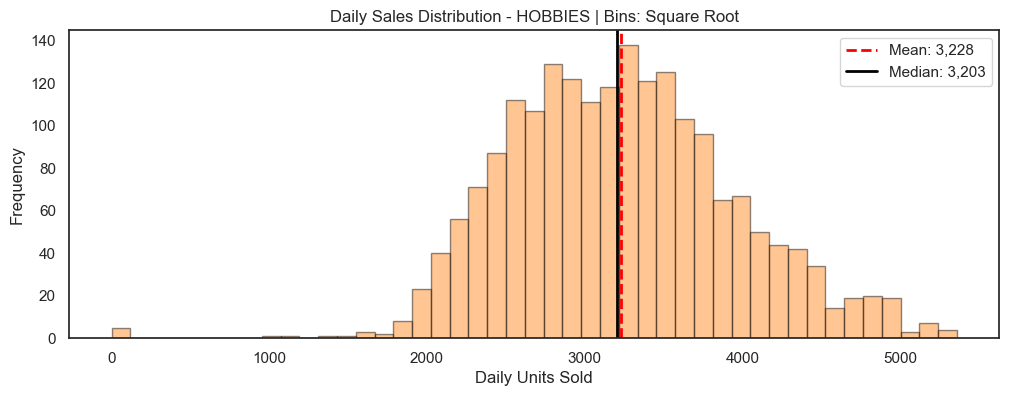

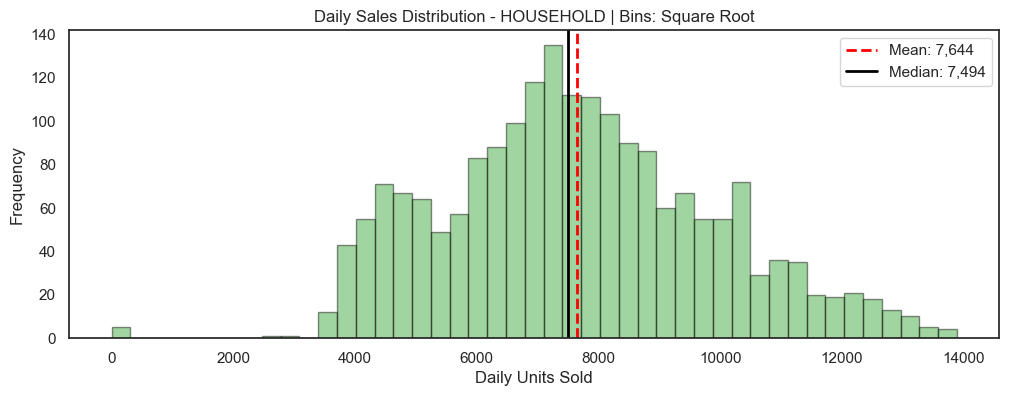

In [114]:
for cat in sorted(category_daily_raw["cat_id"].unique()):
    data = category_daily_raw.loc[category_daily_raw["cat_id"] == cat, "y"]

    mean_sales = data.mean()
    median_sales = data.median()

    ax = data.hist(
        bins="sqrt",  # Square root rule
        figsize=(12, 4),
        color=category_colors.get(cat, "tab:gray"),
        edgecolor="black",
        alpha=0.45,
    )

    ax.axvline(
        mean_sales,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_sales:,.0f}",
    )

    ax.axvline(
        median_sales,
        color="black",
        linestyle="-",
        linewidth=2,
        label=f"Median: {median_sales:,.0f}",
    )

    ax.set_title(f"Daily Sales Distribution - {cat} | Bins: Square Root")
    ax.set_xlabel("Daily Units Sold")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(False)

    plt.show()

In [88]:
print(category_daily_normalized.groupby("cat_id")["y"].describe())

            count          mean          std      min       25%      50%  \
cat_id                                                                     
HOBBIES    1964.0   3236.239258   700.919128   1064.0   2713.75   3204.5   
HOUSEHOLD  1964.0   7663.341797  2191.256836   2729.0   6131.00   7504.0   
FOODS      1964.0  23803.187500  4850.513184  11616.0  20462.50  23386.0   

                75%      max  
cat_id                        
HOBBIES     3681.50   5360.0  
HOUSEHOLD   9110.25  13889.0  
FOODS      26978.75  41447.0  


/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_12203/73686866.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(category_daily_normalized.groupby("cat_id")["y"].describe())


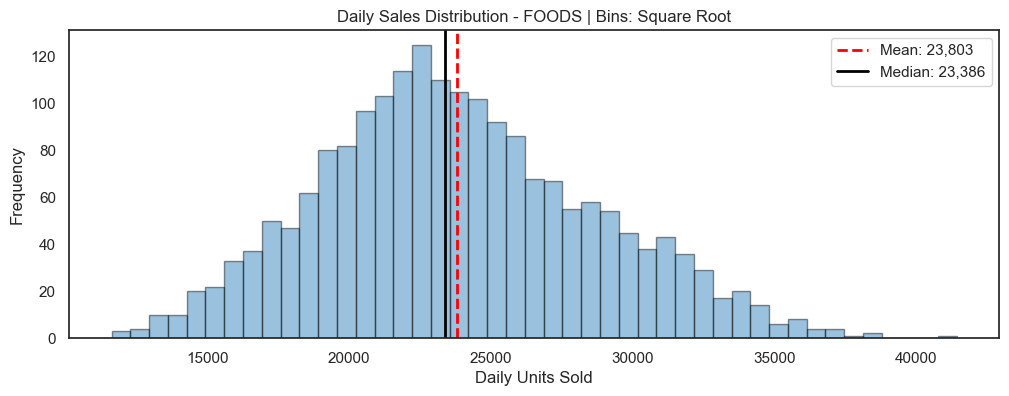

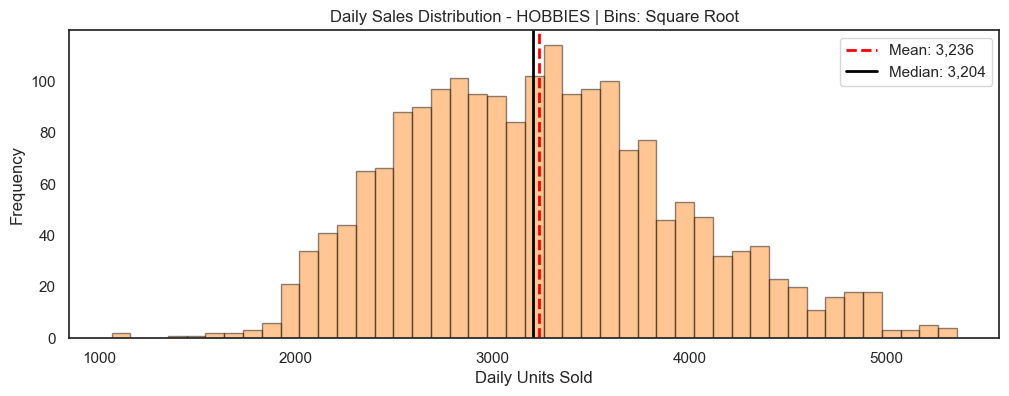

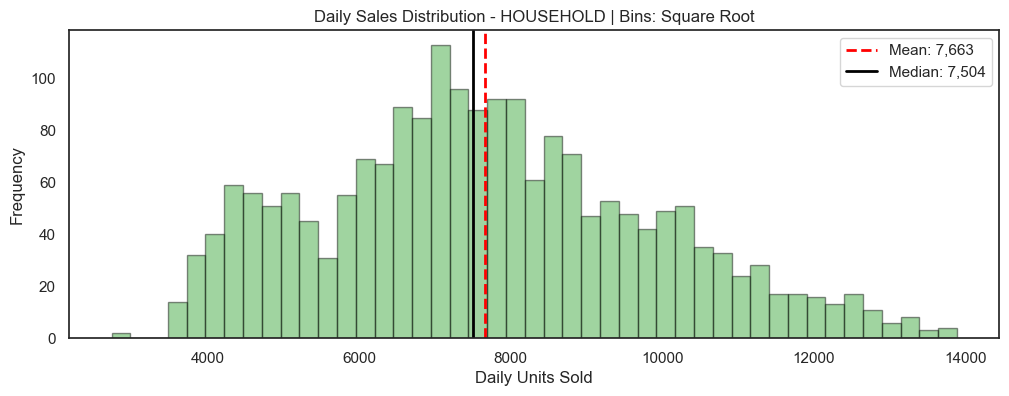

In [115]:
for cat in sorted(category_daily_normalized["cat_id"].unique()):
    data = category_daily_normalized.loc[category_daily_normalized["cat_id"] == cat, "y"]

    mean_sales = data.mean()
    median_sales = data.median()

    ax = data.hist(
        bins="sqrt",  # Square root rule
        figsize=(12, 4),
        color=category_colors.get(cat, "tab:gray"),
        edgecolor="black",
        alpha=0.45,
    )

    ax.axvline(
        mean_sales,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_sales:,.0f}",
    )

    ax.axvline(
        median_sales,
        color="black",
        linestyle="-",
        linewidth=2,
        label=f"Median: {median_sales:,.0f}",
    )

    ax.set_title(f"Daily Sales Distribution - {cat} | Bins: Square Root")
    ax.set_xlabel("Daily Units Sold")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(False)

    plt.show()

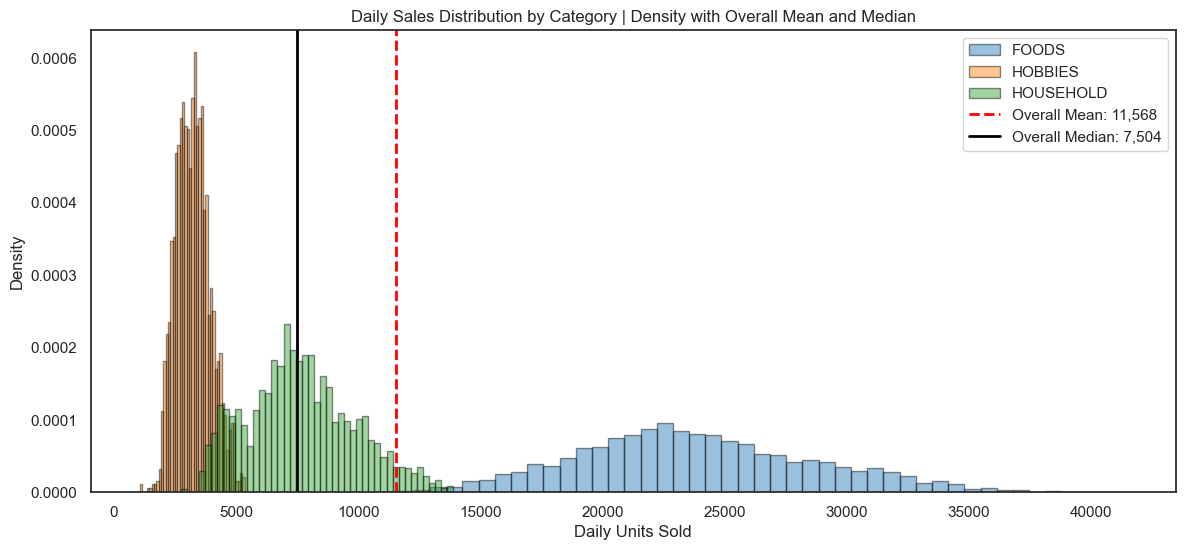

In [116]:
overall_mean = category_daily_normalized["y"].mean()
overall_median = category_daily_normalized["y"].median()

plt.figure(figsize=(14, 6))

for cat in sorted(category_daily_normalized["cat_id"].unique()):
    data = category_daily_normalized.loc[
        category_daily_normalized["cat_id"] == cat,
        "y"
    ]

    plt.hist(
        data,
        bins="sqrt",
        density=True,
        alpha=0.45,
        edgecolor="black",
        label=cat,
        color=category_colors.get(cat, "tab:gray"),
    )

plt.axvline(
    overall_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Overall Mean: {overall_mean:,.0f}",
)

plt.axvline(
    overall_median,
    color="black",
    linestyle="-",
    linewidth=2,
    label=f"Overall Median: {overall_median:,.0f}",
)

plt.title("Daily Sales Distribution by Category | Density with Overall Mean and Median")
plt.xlabel("Daily Units Sold")
plt.ylabel("Density")
plt.legend()
plt.show()

The combined sales distribution is right-skewed, with the overall mean above the overall median. However, the chart also shows that category-level sales operate on materially different scales. HOBBIES, HOUSEHOLD, and FOODS form distinct clusters, which makes the global mean and median poor representatives of demand behavior. Because of this, subsequent distribution analysis, seasonality checks, and forecasting diagnostics should be performed by category rather than on the combined sales series.

In [48]:
m5["dayofweek"] = m5["ds"].dt.day_name()
m5["month"] = m5["ds"].dt.month
m5["year"] = m5["ds"].dt.year

<Axes: title={'center': 'Average Sales by Day of Week'}, xlabel='dayofweek'>

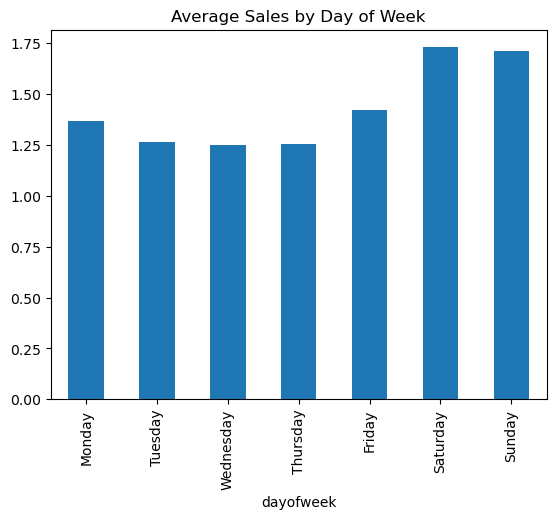

In [49]:
dow_sales = (
    m5.groupby("dayofweek")["y"]
    .mean()
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)

dow_sales.plot(kind="bar", title="Average Sales by Day of Week")

<Axes: title={'center': 'Average Sales by Month'}, xlabel='month'>

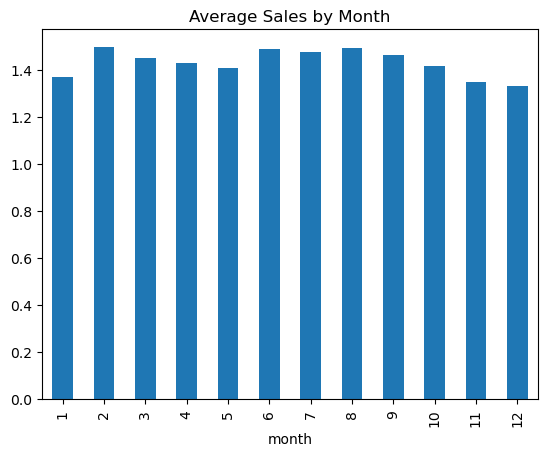

In [50]:
monthly_sales = (
    m5.groupby("month")["y"]
    .mean()
)

monthly_sales.plot(kind="bar", title="Average Sales by Month")

In [51]:
event_sales = (
    m5.groupby("event_type_1")["y"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

event_sales

/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_12203/3853410175.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m5.groupby("event_type_1")["y"]


,mean,median,count
event_type_1,,,
Sporting,1.521645,0.0,433337
Cultural,1.439419,0.0,892435
nan,1.435448,0.0,43727090
Religious,1.431081,0.0,1327427
National,1.216655,0.0,1269651


In [52]:
snap_cols = ["snap_CA", "snap_TX", "snap_WI"]

for col in snap_cols:
    print(col)
    print(m5.groupby(col)["y"].mean())

snap_CA
snap_CA
0    1.390288
1    1.511925
Name: y, dtype: float32
snap_TX
snap_TX
0    1.384205
1    1.524129
Name: y, dtype: float32
snap_WI
snap_WI
0    1.383778
1    1.524975
Name: y, dtype: float32


In [53]:
series_profile = (
    m5.groupby("unique_id")
    .agg(
        avg_daily_sales=("y", "mean"),
        median_daily_sales=("y", "median"),
        total_sales=("y", "sum"),
        zero_sales_rate=("y", lambda s: (s == 0).mean()),
        sales_std=("y", "std"),
        days_observed=("y", "count"),
    )
    .reset_index()
    .merge(S_df, on="unique_id", how="left")
)

series_profile.head()

/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_12203/3485253783.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m5.groupby("unique_id")


,unique_id,avg_daily_sales,median_daily_sales,total_sales,zero_sales_rate,sales_std,days_observed,item_id,dept_id,cat_id,store_id,state_id
0,FOODS_1_001_CA_1,0.797359,0.0,1570.0,0.561199,1.271991,1969,FOODS_1_001,FOODS_1,FOODS,CA_1,CA
1,FOODS_1_001_CA_2,1.161503,1.0,2287.0,0.483494,1.779034,1969,FOODS_1_001,FOODS_1,FOODS,CA_2,CA
2,FOODS_1_001_CA_3,1.202133,0.0,2367.0,0.547994,2.329288,1969,FOODS_1_001,FOODS_1,FOODS,CA_3,CA
3,FOODS_1_001_CA_4,0.361789,0.0,712.0,0.740854,0.734233,1968,FOODS_1_001,FOODS_1,FOODS,CA_4,CA
4,FOODS_1_001_TX_1,0.588415,0.0,1158.0,0.668191,1.312142,1968,FOODS_1_001,FOODS_1,FOODS,TX_1,TX


In [54]:
def demand_type(row):
    if row["zero_sales_rate"] >= 0.70:
        return "Very intermittent"
    elif row["zero_sales_rate"] >= 0.40:
        return "Intermittent"
    elif row["avg_daily_sales"] >= 5:
        return "High volume"
    else:
        return "Regular / low volume"

series_profile["demand_type"] = series_profile.apply(demand_type, axis=1)

series_profile["demand_type"].value_counts()

demand_type
Very intermittent       12294
Intermittent            11476
Regular / low volume     5329
High volume              1391
Name: count, dtype: int64

In [55]:
price_profile = (
    m5.groupby("unique_id")
    .agg(
        avg_price=("sell_price", "mean"),
        min_price=("sell_price", "min"),
        max_price=("sell_price", "max"),
        price_changes=("sell_price", "nunique"),
        total_sales=("y", "sum"),
    )
    .reset_index()
    .merge(S_df, on="unique_id", how="left")
)

price_profile.sort_values("price_changes", ascending=False).head(20)

/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_12203/959195518.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m5.groupby("unique_id")


,unique_id,avg_price,min_price,max_price,price_changes,total_sales,item_id,dept_id,cat_id,store_id,state_id
936,FOODS_1_095_TX_3,4.113125,3.44,4.62,21,1828.0,FOODS_1_095,FOODS_1,FOODS,TX_3,TX
934,FOODS_1_095_TX_1,4.118389,3.44,4.62,21,280.0,FOODS_1_095,FOODS_1,FOODS,TX_1,TX
1267,FOODS_1_129_WI_1,7.995534,5.04,9.00,20,2497.0,FOODS_1_129,FOODS_1,FOODS,WI_1,WI
935,FOODS_1_095_TX_2,4.104251,3.44,4.62,18,811.0,FOODS_1_095,FOODS_1,FOODS,TX_2,TX
930,FOODS_1_095_CA_1,3.026816,2.66,3.42,18,403.0,FOODS_1_095,FOODS_1,FOODS,CA_1,CA
931,FOODS_1_095_CA_2,3.026387,2.66,3.42,18,915.0,FOODS_1_095,FOODS_1,FOODS,CA_2,CA
1269,FOODS_1_129_WI_3,8.033463,5.04,9.00,18,2994.0,FOODS_1_129,FOODS_1,FOODS,WI_3,WI
1268,FOODS_1_129_WI_2,8.010036,7.02,9.00,18,5062.0,FOODS_1_129,FOODS_1,FOODS,WI_2,WI
933,FOODS_1_095_CA_4,3.033855,2.66,3.42,18,1411.0,FOODS_1_095,FOODS_1,FOODS,CA_4,CA
948,FOODS_1_096_WI_2,7.989913,7.02,9.00,17,32593.0,FOODS_1_096,FOODS_1,FOODS,WI_2,WI


<Axes: title={'center': 'Sales and Price: FOODS_3_090_CA_3'}, xlabel='ds'>

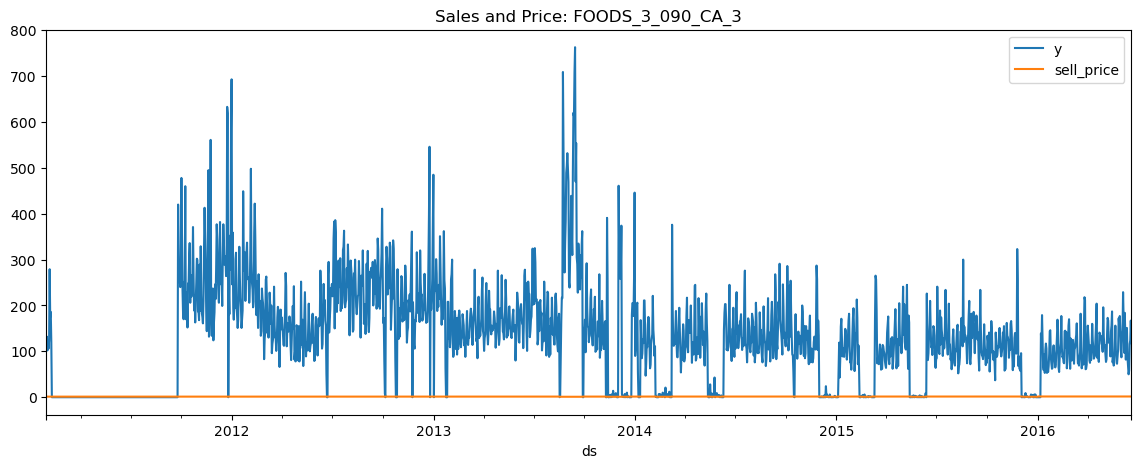

In [56]:
sample_id = series_profile.sort_values("total_sales", ascending=False)["unique_id"].iloc[0]

sample = m5[m5["unique_id"] == sample_id].copy()

sample.plot(x="ds", y=["y", "sell_price"], figsize=(14, 5), title=f"Sales and Price: {sample_id}")

In [57]:
import numpy as np

H = 28

def evaluate_baseline_one_series(df):
    df = df.sort_values("ds")
    
    train = df.iloc[:-H].copy()
    test = df.iloc[-H:].copy()
    
    last_value = train["y"].iloc[-1]
    mean_28 = train["y"].tail(28).mean()
    mean_56 = train["y"].tail(56).mean()
    
    test = test.copy()
    test["naive_last"] = last_value
    test["ma_28"] = mean_28
    test["ma_56"] = mean_56
    
    return test

sample_forecast = evaluate_baseline_one_series(sample)
sample_forecast.head()

,unique_id,ds,y,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,...,dept_id,cat_id,store_id,state_id,dayofweek,month,year,naive_last,ma_28,ma_56
10680195,FOODS_3_090_CA_3,2016-05-23,98.0,nan,nan,nan,nan,0,0,0,...,FOODS_3,FOODS,CA_3,CA,Monday,5,2016,99.0,119.89286,115.125
10680196,FOODS_3_090_CA_3,2016-05-24,73.0,nan,nan,nan,nan,0,0,0,...,FOODS_3,FOODS,CA_3,CA,Tuesday,5,2016,99.0,119.89286,115.125
10680197,FOODS_3_090_CA_3,2016-05-25,88.0,nan,nan,nan,nan,0,0,0,...,FOODS_3,FOODS,CA_3,CA,Wednesday,5,2016,99.0,119.89286,115.125
10680198,FOODS_3_090_CA_3,2016-05-26,104.0,nan,nan,nan,nan,0,0,0,...,FOODS_3,FOODS,CA_3,CA,Thursday,5,2016,99.0,119.89286,115.125
10680199,FOODS_3_090_CA_3,2016-05-27,172.0,nan,nan,nan,nan,0,0,0,...,FOODS_3,FOODS,CA_3,CA,Friday,5,2016,99.0,119.89286,115.125


In [58]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else np.sum(np.abs(y_true - y_pred)) / denom

for model in ["naive_last", "ma_28", "ma_56"]:
    print(model)
    print("MAE:", mae(sample_forecast["y"], sample_forecast[model]))
    print("WAPE:", wape(sample_forecast["y"], sample_forecast[model]))

naive_last
MAE: 38.857143
WAPE: 0.3149971
ma_28
MAE: 35.857143
WAPE: 0.2906775
ma_56
MAE: 36.125
WAPE: 0.29284889
